Titanic dataset

In [47]:

import pandas as pd

data_frame = pd.read_csv("../datasets/raw/titanic/train.csv")

print("\nFirst 5 rows of the Titanic dataset:\n")
display(data_frame.head())

print("\nShape of the Titanic dataset:\n")
print(data_frame.shape)

print("\nColumns of the Titanic dataset:\n")
print(data_frame.columns)

print("\nData types of the Titanic dataset:\n")
print(data_frame.dtypes)



First 5 rows of the Titanic dataset:



,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S



Shape of the Titanic dataset:

(891, 12)

Columns of the Titanic dataset:

Index(['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp',
       'Parch', 'Ticket', 'Fare', 'Cabin', 'Embarked'],
      dtype='str')

Data types of the Titanic dataset:

PassengerId      int64
Survived         int64
Pclass           int64
Name               str
Sex                str
Age            float64
SibSp            int64
Parch            int64
Ticket             str
Fare           float64
Cabin              str
Embarked           str
dtype: object


In [48]:
# Information about the Titanic dataset
print(data_frame.info())
print("\nNumber of Missing values in the Titanic dataset:\n")
display(data_frame.isnull().sum())


<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    str    
 4   Sex          891 non-null    str    
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    str    
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    str    
 11  Embarked     889 non-null    str    
dtypes: float64(2), int64(5), str(5)
memory usage: 83.7 KB
None

Number of Missing values in the Titanic dataset:



PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

In [49]:
# Percentage of missing values in the Titanic dataset
print("\nPercentage of Missing values in the Titanic dataset:\n")
display(data_frame.isnull().mean()*100)


Percentage of Missing values in the Titanic dataset:



PassengerId     0.000000
Survived        0.000000
Pclass          0.000000
Name            0.000000
Sex             0.000000
Age            19.865320
SibSp           0.000000
Parch           0.000000
Ticket          0.000000
Fare            0.000000
Cabin          77.104377
Embarked        0.224467
dtype: float64

In [50]:
# Mean and median values of the 'Age' column in the Titanic dataset

print("\nAge mean value:")
print(data_frame['Age'].mean())

print("\nAge median value:")
print(data_frame['Age'].median())


Age mean value:
29.69911764705882

Age median value:
28.0


In [51]:
# Describe the 'Age' column in the Titanic dataset
data_frame['Age'].describe()

count    714.000000
mean      29.699118
std       14.526497
min        0.420000
25%       20.125000
50%       28.000000
75%       38.000000
max       80.000000
Name: Age, dtype: float64

<Axes: >

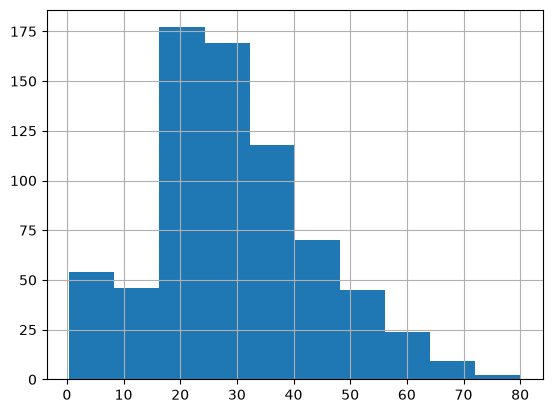

In [52]:
# Histogram of the 'Age' column in the Titanic dataset
data_frame['Age'].hist()

In [53]:
# DataFrame after filling missing values in the 'Age' column with the median value
processed_data= data_frame.copy()
processed_data['Age']=processed_data['Age'].fillna(processed_data['Age'].median())
processed_data.isnull().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age              0
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

In [54]:
#Verifying the mode of the 'Embarked' column in the Titanic dataset
processed_data['Embarked'].mode()[0]

'S'

In [55]:
# Filling missing values in the 'Embarked' column with the mode value
processed_data['Embarked']=processed_data['Embarked'].fillna(processed_data['Embarked'].mode()[0])
processed_data.isnull().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age              0
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         0
dtype: int64

In [56]:
#Cabin column Investigation

# Checking the number of unique values in the 'Cabin' column
print("\nFirst 15 non-null values of the 'Cabin' column in the Titanic dataset:\n")
display(processed_data['Cabin'].dropna().head(15))

print("\nFrequency of Deck values in the 'Cabin' column:\n")
print(processed_data['Cabin'].dropna().str[0].value_counts())


First 15 non-null values of the 'Cabin' column in the Titanic dataset:



1             C85
3            C123
6             E46
10             G6
11           C103
21            D56
23             A6
27    C23 C25 C27
31            B78
52            D33
54            B30
55            C52
61            B28
62            C83
66            F33
Name: Cabin, dtype: str


Frequency of Deck values in the 'Cabin' column:

Cabin
C    59
B    47
D    33
E    32
A    15
F    13
G     4
T     1
Name: count, dtype: int64


In [57]:
# Creating a new 'Deck' column from the first character of the 'Cabin' column
processed_data['Deck']=processed_data['Cabin'].str[0]
processed_data[['Cabin','Deck']].head(15)

,Cabin,Deck
0,NaN,NaN
1,C85,C
2,NaN,NaN
3,C123,C
4,NaN,NaN
5,NaN,NaN
6,E46,E
7,NaN,NaN
8,NaN,NaN
9,NaN,NaN


In [58]:
# Creating a new 'HasCabin' column to indicate whether a passenger has a cabin or not
processed_data['HasCabin']=processed_data['Cabin'].notnull().astype(int)
processed_data[['Cabin','HasCabin']].head(15)

,Cabin,HasCabin
0,NaN,0
1,C85,1
2,NaN,0
3,C123,1
4,NaN,0
5,NaN,0
6,E46,1
7,NaN,0
8,NaN,0
9,NaN,0


In [59]:
# Checking the number of passengers with and without a cabin
print("\nNumber of passengers with and without a cabin:\n")
print(processed_data['HasCabin'].value_counts())

# Checking the survival rate based on whether a passenger has a cabin or not
print("\nSurvival rate based on cabin presence:\n")
print(processed_data.groupby(['HasCabin'])['Survived'].mean()*100)


Number of passengers with and without a cabin:

HasCabin
0    687
1    204
Name: count, dtype: int64

Survival rate based on cabin presence:

HasCabin
0    29.985444
1    66.666667
Name: Survived, dtype: float64


In [60]:
# Cross-tabulation of passenger class and cabin presence
pd.crosstab(
    processed_data['Pclass'],
    processed_data['HasCabin'],
    normalize='index'
    )*100

HasCabin,0,1
Pclass,,
1,18.518519,81.481481
2,91.304348,8.695652
3,97.556008,2.443992


In [61]:
# Survival rate based on passenger class and cabin presence
processed_data.groupby(['Pclass','HasCabin'])['Survived'].mean()*100

Pclass  HasCabin
1       0           47.500000
        1           66.477273
2       0           44.047619
        1           81.250000
3       0           23.590814
        1           50.000000
Name: Survived, dtype: float64

In [62]:
# Creating a DataFrame to show survival rate based on passenger class and cabin presence
survival_by_cabin_class = (
    processed_data
    .groupby(['Pclass','HasCabin'])['Survived']
    .mean()
    .reset_index()
    )
survival_by_cabin_class['SurvivalRate']= survival_by_cabin_class['Survived']*100

survival_by_cabin_class

,Pclass,HasCabin,Survived,SurvivalRate
0,1,0,0.475000,47.500000
1,1,1,0.664773,66.477273
2,2,0,0.440476,44.047619
3,2,1,0.812500,81.250000
4,3,0,0.235908,23.590814
5,3,1,0.500000,50.000000


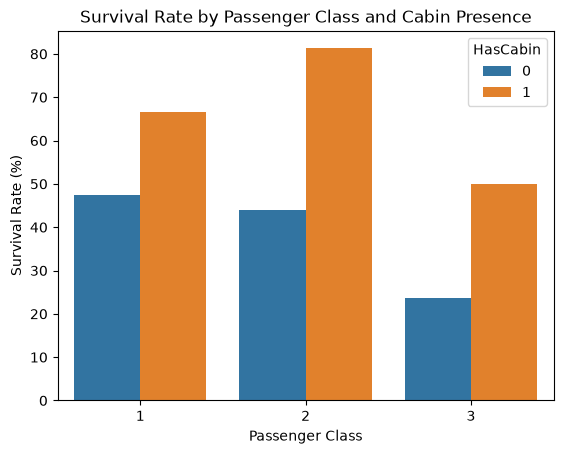

In [63]:
# Visualizing the survival rate based on passenger class and cabin presence using a bar plot

import matplotlib.pyplot as plt
import seaborn as sns

sns.barplot(
    data= survival_by_cabin_class,
    x='Pclass',
    y='SurvivalRate',
    hue='HasCabin',
    errorbar=None
)

plt.title('Survival Rate by Passenger Class and Cabin Presence')
plt.xlabel('Passenger Class')
plt.ylabel('Survival Rate (%)')

plt.show()

In [64]:
print("\nFrequency of Deck values in the 'Cabin' column:\n")
print(processed_data['Deck'].value_counts())

print("\nSurvival rate based on Deck:\n")
print(processed_data.groupby('Deck')['Survived'].mean()*100)


Frequency of Deck values in the 'Cabin' column:

Deck
C    59
B    47
D    33
E    32
A    15
F    13
G     4
T     1
Name: count, dtype: int64

Survival rate based on Deck:

Deck
A    46.666667
B    74.468085
C    59.322034
D    75.757576
E    75.000000
F    61.538462
G    50.000000
T     0.000000
Name: Survived, dtype: float64


In [65]:
# Creating a DataFrame to show survival rate based on Deck
deck_summary = (
    processed_data
    .groupby('Deck')['Survived']
    .agg(['count','mean'])
)

deck_summary

,count,mean
Deck,,
A,15,0.466667
B,47,0.744681
C,59,0.593220
D,33,0.757576
E,32,0.750000
F,13,0.615385
G,4,0.500000
T,1,0.000000


In [66]:
# Calculate survival rate based on Deck and rename the 'count' column to 'PassengerCount'

deck_summary['SurvivalRate'] = deck_summary['mean']*100
deck_summary = deck_summary.rename(
    columns={'count': 'PassengerCount'}
)

deck_summary

,PassengerCount,mean,SurvivalRate
Deck,,,
A,15,0.466667,46.666667
B,47,0.744681,74.468085
C,59,0.593220,59.322034
D,33,0.757576,75.757576
E,32,0.750000,75.000000
F,13,0.615385,61.538462
G,4,0.500000,50.000000
T,1,0.000000,0.000000


In [67]:

# Deleting the 'mean' column and resetting the index of the deck_summary DataFrame

deck_summary = deck_summary.drop(columns=['mean']).reset_index()
deck_summary

,Deck,PassengerCount,SurvivalRate
0,A,15,46.666667
1,B,47,74.468085
2,C,59,59.322034
3,D,33,75.757576
4,E,32,75.000000
5,F,13,61.538462
6,G,4,50.000000
7,T,1,0.000000


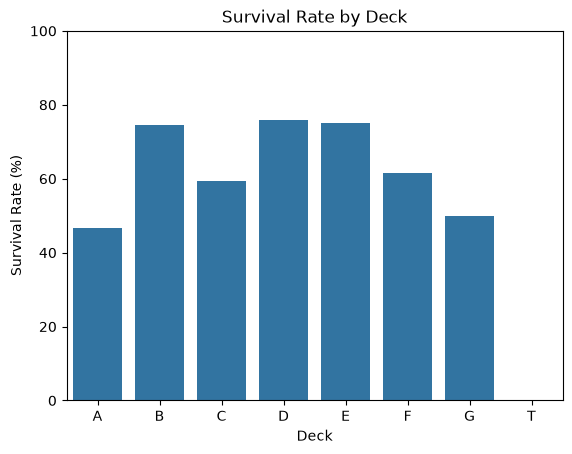

In [68]:
# Visualizing the survival rate based on Deck using a bar plot
sns.barplot(
    data=deck_summary,
    x='Deck',
    y='SurvivalRate',
    errorbar=None
)

plt.title('Survival Rate by Deck')
plt.xlabel('Deck')
plt.ylabel('Survival Rate (%)')
plt.ylim(0,100)

plt.show()

In [69]:
processed_data['Deck']=processed_data['Deck'].fillna('Unknown')
print(processed_data['Deck'].value_counts())

print("\nNumber of Missing values in the 'Deck' column after filling missing values:\n")
print(processed_data['Deck'].isnull().sum())

Deck
Unknown    687
C           59
B           47
D           33
E           32
A           15
F           13
G            4
T            1
Name: count, dtype: int64

Number of Missing values in the 'Deck' column after filling missing values:

0


In [70]:
# Calculating the survival rate for each deck
processed_data.groupby(['Deck'])['Survived'].mean()*100

Deck
A          46.666667
B          74.468085
C          59.322034
D          75.757576
E          75.000000
F          61.538462
G          50.000000
T           0.000000
Unknown    29.985444
Name: Survived, dtype: float64

In [71]:
print("\nNumber of duplicate rows in the Titanic dataset:\n")
print(processed_data.duplicated().sum())

print("\nData types of the processed Titanic dataset:")
processed_data.dtypes


Number of duplicate rows in the Titanic dataset:

0

Data types of the processed Titanic dataset:


PassengerId      int64
Survived         int64
Pclass           int64
Name               str
Sex                str
Age            float64
SibSp            int64
Parch            int64
Ticket             str
Fare           float64
Cabin              str
Embarked           str
Deck               str
HasCabin         int64
dtype: object

In [72]:
processed_data['Fare'].describe()

count    891.000000
mean      32.204208
std       49.693429
min        0.000000
25%        7.910400
50%       14.454200
75%       31.000000
max      512.329200
Name: Fare, dtype: float64

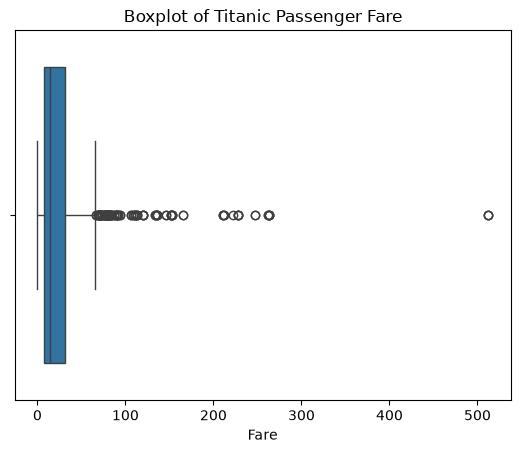

In [73]:
# Visualizing the distribution of the 'Fare' column using a boxplot
sns.boxplot(x=processed_data['Fare'])

plt.title('Boxplot of Titanic Passenger Fare')
plt.xlabel('Fare')

plt.show()

In [74]:
# Calculating the first quartile (Q1), third quartile (Q3), and interquartile range (IQR) for the 'Fare' column
Q1= processed_data['Fare'].quantile(0.25)
Q3= processed_data['Fare'].quantile(0.75)

IRQ= Q3-Q1

lower_bound= Q1-1.5*IRQ
upper_bound= Q3+1.5*IRQ

print("Q1:", Q1)
print("Q3:", Q3)
print("IRQ:", IRQ)
print("Lower Bound:", lower_bound)
print("Upper Bound:", upper_bound)

Q1: 7.9104
Q3: 31.0
IRQ: 23.0896
Lower Bound: -26.724
Upper Bound: 65.6344


In [75]:
# Identifying fare outliers in the processed Titanic dataset
fare_outliers= processed_data[processed_data['Fare']>upper_bound]
print("The number of fare outliers:",fare_outliers.shape[0])

The number of fare outliers: 116


In [76]:
fare_outliers[['PassengerId','Pclass','Fare','Ticket','Cabin','Survived']].sort_values(by='Fare',ascending=False).head(15)

,PassengerId,Pclass,Fare,Ticket,Cabin,Survived
258,259,1,512.3292,PC 17755,NaN,1
737,738,1,512.3292,PC 17755,B101,1
679,680,1,512.3292,PC 17755,B51 B53 B55,1
27,28,1,263.0000,19950,C23 C25 C27,0
341,342,1,263.0000,19950,C23 C25 C27,1
438,439,1,263.0000,19950,C23 C25 C27,0
88,89,1,263.0000,19950,C23 C25 C27,1
311,312,1,262.3750,PC 17608,B57 B59 B63 B66,1
742,743,1,262.3750,PC 17608,B57 B59 B63 B66,1
299,300,1,247.5208,PC 17558,B58 B60,1


In [77]:
processed_data.groupby('Pclass')['Fare'].describe()

,count,mean,std,min,25%,50%,75%,max
Pclass,,,,,,,,
1,216.0,84.154687,78.380373,0.0,30.92395,60.2875,93.5,512.3292
2,184.0,20.662183,13.417399,0.0,13.00000,14.2500,26.0,73.5000
3,491.0,13.675550,11.778142,0.0,7.75000,8.0500,15.5,69.5500
